# Crowd-Informed Investing Model

Aggregates sentiment signals from Reddit, financial news, and social sources to generate investment scores. Pipeline:

1. **Data Collection** — Reddit scraped via Playwright (no API key needed), NewsAPI headlines
2. **Sentiment Analysis** — VADER + FinBERT-style keyword weighting
3. **Signal Aggregation** — Volume-weighted crowd sentiment score per ticker
4. **Price Integration** — yfinance for OHLCV; momentum + sentiment fusion
5. **Scoring & Ranking** — Final composite score with buy/hold/sell signal
6. **Backtest** — Rolling signal accuracy over historical data

## 0. Install Dependencies

In [43]:
# Run once to install required packages
import subprocess, sys

packages = [
    "playwright",     # Headless browser for Reddit scraping (no API key needed)
    "nest_asyncio",   # Allow async Playwright inside Jupyter's event loop
    "newsapi-python", # News headlines
    "vaderSentiment", # Sentiment analysis
    "yfinance",       # Stock price data
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "requests",
    "scipy",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# Download Chromium browser binary (only needs to run once)
print("Installing Chromium for Playwright...")
subprocess.check_call([sys.executable, "-m", "playwright", "install", "chromium", "--with-deps"])

print("All packages installed.")

Installing Chromium for Playwright...
All packages installed.


## 1. Configuration

In [44]:
import os

# ── Reddit OAuth credentials (free — no PRAW needed) ─────────────────────────
# 1. Go to https://www.reddit.com/prefs/apps and click "create another app"
# 2. Choose "script", give it any name, set redirect URI to http://localhost:8080
# 3. Copy the client ID (under the app name) and the secret
# Then either set them as env vars or paste directly below.

REDDIT_CLIENT_ID     = os.getenv("REDDIT_CLIENT_ID",     "YOUR_CLIENT_ID")
REDDIT_CLIENT_SECRET = os.getenv("REDDIT_CLIENT_SECRET", "YOUR_CLIENT_SECRET")

# ── NewsAPI (optional) ────────────────────────────────────────────────────────
NEWSAPI_KEY = os.getenv("NEWSAPI_KEY", "YOUR_NEWSAPI_KEY")

# ── Watchlist ─────────────────────────────────────────────────────────────────
TICKERS = ["AAPL", "MSFT", "NVDA", "TSLA", "GOOGL", "AMZN", "META", "AMD"]

# ── Model Parameters ─────────────────────────────────────────────────────────
REDDIT_POST_LIMIT   = 200   # total posts to collect across all subreddits
CRAWL_DELAY_S       = 1.0   # polite pause between paginated requests
NEWS_LOOKBACK_DAYS  = 7     # days of headlines
PRICE_LOOKBACK_DAYS = 90    # days of price history for momentum

# Weights for composite score (must sum to 1)
W_REDDIT_SENTIMENT  = 0.35
W_NEWS_SENTIMENT    = 0.25
W_MENTION_VELOCITY  = 0.20
W_PRICE_MOMENTUM    = 0.20

# Score thresholds
BUY_THRESHOLD  =  0.25
SELL_THRESHOLD = -0.25

REDDIT_DEMO = (REDDIT_CLIENT_ID  == "YOUR_CLIENT_ID")
NEWS_DEMO   = (NEWSAPI_KEY       == "YOUR_NEWSAPI_KEY")
print(f"Reddit demo mode: {REDDIT_DEMO}  → set REDDIT_CLIENT_ID + REDDIT_CLIENT_SECRET")
print(f"News   demo mode: {NEWS_DEMO}    → set NEWSAPI_KEY")

## 2. Data Collection

In [45]:
import requests
from newsapi import NewsApiClient
from datetime import datetime, timedelta
import pandas as pd
import re
import time

# ── Ticker mention extractor ──────────────────────────────────────────────────
_ticker_pattern = re.compile(
    r"\b(" + "|".join(re.escape(t) for t in TICKERS) + r")\b"
)

def extract_tickers(text: str) -> list[str]:
    """Return list of watchlist tickers mentioned in text."""
    return list(set(_ticker_pattern.findall(text.upper())))


# ── Reddit OAuth helper ───────────────────────────────────────────────────────
_reddit_token: str | None = None

def _get_reddit_token() -> str:
    """Fetch a client_credentials OAuth token (no user login needed)."""
    global _reddit_token
    if _reddit_token:
        return _reddit_token
    resp = requests.post(
        "https://www.reddit.com/api/v1/access_token",
        auth=(REDDIT_CLIENT_ID, REDDIT_CLIENT_SECRET),
        data={"grant_type": "client_credentials"},
        headers={"User-Agent": "crowd_investing_model/0.1 (research)"},
        timeout=10,
    )
    resp.raise_for_status()
    _reddit_token = resp.json()["access_token"]
    return _reddit_token


# ── Reddit scraper (official OAuth API — no PRAW) ─────────────────────────────
SUBREDDITS = ["wallstreetbets", "investing", "stocks", "StockMarket", "SecurityAnalysis"]


def fetch_reddit_posts(limit: int = REDDIT_POST_LIMIT) -> pd.DataFrame:
    """
    Fetch hot posts via Reddit's OAuth API using client_credentials.
    No PRAW needed — just a free Reddit app (script type) for credentials.
    Register at: https://www.reddit.com/prefs/apps
    """
    if REDDIT_DEMO:
        print("  ℹ Reddit credentials not set — using demo data")
        return _demo_reddit_posts()

    try:
        token = _get_reddit_token()
    except Exception as e:
        print(f"  ⚠ Token error: {e} — using demo data")
        return _demo_reddit_posts()

    headers = {
        "Authorization": f"bearer {token}",
        "User-Agent":    "crowd_investing_model/0.1 (research)",
    }

    rows = []
    posts_per_sub = max(limit // len(SUBREDDITS), 10)

    for sub_name in SUBREDDITS:
        print(f"  Fetching r/{sub_name}...")
        collected = 0
        after     = None

        while collected < posts_per_sub:
            params = {"limit": min(100, posts_per_sub - collected)}
            if after:
                params["after"] = after

            try:
                resp = requests.get(
                    f"https://oauth.reddit.com/r/{sub_name}/hot",
                    headers=headers,
                    params=params,
                    timeout=15,
                )
                resp.raise_for_status()
                data = resp.json()["data"]
            except Exception as e:
                print(f"    ⚠ Request error: {e}")
                break

            posts = data.get("children", [])
            if not posts:
                break

            for post in posts:
                if collected >= posts_per_sub:
                    break
                p = post["data"]
                if p.get("stickied"):
                    continue

                title    = p.get("title", "")
                selftext = p.get("selftext", "")[:500]
                tickers  = extract_tickers((title + " " + selftext).upper())
                if not tickers:
                    continue

                for ticker in tickers:
                    rows.append({
                        "source":       "reddit",
                        "subreddit":    sub_name,
                        "ticker":       ticker,
                        "text":         (title + " " + selftext).strip(),
                        "score":        int(p.get("score", 1)),
                        "comments":     int(p.get("num_comments", 0)),
                        "upvote_ratio": float(p.get("upvote_ratio", 0.72)),
                        "created_utc":  datetime.utcfromtimestamp(p.get("created_utc", 0)),
                    })
                collected += 1

            after = data.get("after")
            if not after:
                break
            time.sleep(CRAWL_DELAY_S)

    print(f"  ✓ Collected {len(rows)} ticker mentions from Reddit")
    if not rows:
        print("  ⚠ No data returned — falling back to demo data")
        return _demo_reddit_posts()
    return pd.DataFrame(rows)


# ── News collection ───────────────────────────────────────────────────────────
def fetch_news_articles() -> pd.DataFrame:
    """Fetch news headlines for each ticker via NewsAPI."""
    if NEWS_DEMO:
        return _demo_news_articles()

    newsapi   = NewsApiClient(api_key=NEWSAPI_KEY)
    from_date = (datetime.now() - timedelta(days=NEWS_LOOKBACK_DAYS)).strftime("%Y-%m-%d")
    rows      = []

    name_map = {
        "AAPL": "Apple", "MSFT": "Microsoft", "NVDA": "Nvidia",
        "TSLA": "Tesla",  "GOOGL": "Google",   "AMZN": "Amazon",
        "META": "Meta",   "AMD": "AMD",
    }

    for ticker in TICKERS:
        query = f"{ticker} OR {name_map.get(ticker, ticker)} stock"
        try:
            resp = newsapi.get_everything(
                q=query, language="en", from_param=from_date,
                sort_by="relevancy", page_size=20,
            )
            for art in resp.get("articles", []):
                rows.append({
                    "source":       "news",
                    "outlet":       art["source"]["name"],
                    "ticker":       ticker,
                    "text":         (art["title"] or "") + " " + (art["description"] or ""),
                    "score":        1,
                    "published_at": pd.to_datetime(art["publishedAt"]),
                })
        except Exception as e:
            print(f"NewsAPI error for {ticker}: {e}")
        time.sleep(0.3)

    return pd.DataFrame(rows)


print("Data collection functions ready.")

In [46]:
import numpy as np
import random

# ── Demo data generators (news fallback + Reddit fallback if scraping blocked) ─
random.seed(42)
np.random.seed(42)

DEMO_REDDIT_TEMPLATES = [
    "{t} is going to the moon! 🚀 Loaded up on calls.",
    "Anyone else holding {t}? Earnings beat was massive.",
    "DD: Why {t} is massively undervalued right now",
    "Sold all my {t} — the fundamentals don't support this valuation",
    "{t} just announced a stock buyback. Bullish.",
    "Is {t} a value trap? Revenue growth is slowing.",
    "{t} short squeeze incoming. Short interest at 20%.",
    "Why I'm bearish on {t} for the next quarter",
    "{t} just hit ATH. Is it too late to buy?",
    "Averaging down on {t}. Long-term conviction unchanged.",
]

DEMO_NEWS_TEMPLATES = [
    "{company} reports record quarterly earnings, shares rise",
    "{company} faces regulatory scrutiny in EU antitrust probe",
    "{company} announces $10B share buyback program",
    "Analysts upgrade {company} to 'Buy' with raised price target",
    "{company} misses revenue estimates for the second straight quarter",
    "{company} CEO signals strong guidance for next fiscal year",
    "Hedge funds increase positions in {company}",
    "{company} stock falls on disappointing product launch",
]

COMPANY_NAMES = {
    "AAPL": "Apple", "MSFT": "Microsoft", "NVDA": "Nvidia",
    "TSLA": "Tesla",  "GOOGL": "Google",   "AMZN": "Amazon",
    "META": "Meta",   "AMD": "AMD",
}


def _demo_reddit_posts() -> pd.DataFrame:
    rows = []
    now  = datetime.utcnow()
    for ticker in TICKERS:
        n = random.randint(10, 60)
        for _ in range(n):
            template = random.choice(DEMO_REDDIT_TEMPLATES)
            rows.append({
                "source":       "reddit",
                "subreddit":    random.choice(SUBREDDITS),
                "ticker":       ticker,
                "text":         template.format(t=ticker),
                "score":        int(np.random.lognormal(5, 2)),
                "comments":     int(np.random.lognormal(3, 1.5)),
                "upvote_ratio": float(np.clip(np.random.normal(0.72, 0.12), 0.4, 1.0)),
                "created_utc":  now - timedelta(hours=random.randint(0, 168)),
            })
    return pd.DataFrame(rows)


def _demo_news_articles() -> pd.DataFrame:
    rows    = []
    now     = datetime.utcnow()
    outlets = ["Reuters", "Bloomberg", "WSJ", "CNBC", "MarketWatch", "Seeking Alpha"]
    for ticker in TICKERS:
        n = random.randint(5, 20)
        for _ in range(n):
            template = random.choice(DEMO_NEWS_TEMPLATES)
            rows.append({
                "source":       "news",
                "outlet":       random.choice(outlets),
                "ticker":       ticker,
                "text":         template.format(company=COMPANY_NAMES[ticker]),
                "score":        1,
                "published_at": now - timedelta(hours=random.randint(0, 168)),
            })
    return pd.DataFrame(rows)


print("Demo data generators loaded.")

Demo data generators loaded.


In [47]:
# Fetch data
print("Fetching Reddit posts via Playwright...")
df_reddit = fetch_reddit_posts()
print(f"  → {len(df_reddit)} Reddit mentions across {df_reddit['ticker'].nunique()} tickers")

print("Fetching news articles...")
df_news = fetch_news_articles()
print(f"  → {len(df_news)} news articles across {df_news['ticker'].nunique()} tickers")

## 3. Sentiment Analysis

In [48]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Base VADER analyzer
_vader = SentimentIntensityAnalyzer()

# ── Finance-specific lexicon boosts ───────────────────────────────────────────
# VADER's default lexicon is news-general; these terms are systematically
# misscored in finance contexts.
FINANCE_LEXICON = {
    # Bullish terms
    "moon": 3.0, "mooning": 3.0, "rocket": 2.5, "bull": 2.0, "bullish": 2.5,
    "undervalued": 2.0, "beat": 2.0, "upgrade": 2.0, "buyback": 2.0,
    "breakout": 2.0, "squeeze": 1.5, "catalyst": 1.5, "conviction": 1.5,
    "record": 1.5, "outperform": 2.0, "strong": 1.5, "atl": -2.0, "ath": 1.5,
    # Bearish terms
    "bear": -2.0, "bearish": -2.5, "overvalued": -2.0, "miss": -2.0,
    "downgrade": -2.0, "short": -1.5, "fraud": -3.5, "scrutiny": -1.5,
    "trap": -2.0, "collapse": -3.0, "crash": -3.0, "bubble": -2.0,
    "sell": -1.5, "sold": -1.0, "dump": -2.5, "disappointing": -2.0,
    # WSB-specific sentiment
    "yolo": 1.5, "hodl": 1.0, "diamond hands": 2.0, "paper hands": -1.5,
    "to the moon": 3.0, "tendies": 1.5, "puts": -1.0, "calls": 1.0,
}
_vader.lexicon.update(FINANCE_LEXICON)


def compute_sentiment(text: str) -> float:
    """Return compound VADER score in [-1, +1]."""
    scores = _vader.polarity_scores(str(text))
    return scores["compound"]


def weighted_sentiment(text: str, score: float, upvote_ratio: float = 0.7) -> float:
    """
    Scale raw sentiment by log(engagement) and upvote ratio.
    High-engagement, high-consensus posts carry more weight.
    """
    base = compute_sentiment(text)
    engagement_weight = np.log1p(max(score, 1))
    consensus_weight  = upvote_ratio  # 1.0 = all upvotes, 0.5 = controversial
    return base * engagement_weight * consensus_weight


# Apply to Reddit data
df_reddit["raw_sentiment"]      = df_reddit["text"].map(compute_sentiment)
df_reddit["weighted_sentiment"] = df_reddit.apply(
    lambda r: weighted_sentiment(r["text"], r["score"], r["upvote_ratio"]), axis=1
)

# Apply to News data (no upvote ratio; weight by article = 1)
df_news["raw_sentiment"]        = df_news["text"].map(compute_sentiment)
df_news["weighted_sentiment"]   = df_news["raw_sentiment"]

print("Sentiment computed.")
print(f"Reddit mean sentiment: {df_reddit['raw_sentiment'].mean():.3f}")
print(f"News   mean sentiment: {df_news['raw_sentiment'].mean():.3f}")

Sentiment computed.
Reddit mean sentiment: 0.230
News   mean sentiment: 0.204


/tmp/ipykernel_6362/2454780303.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6362/2454780303.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


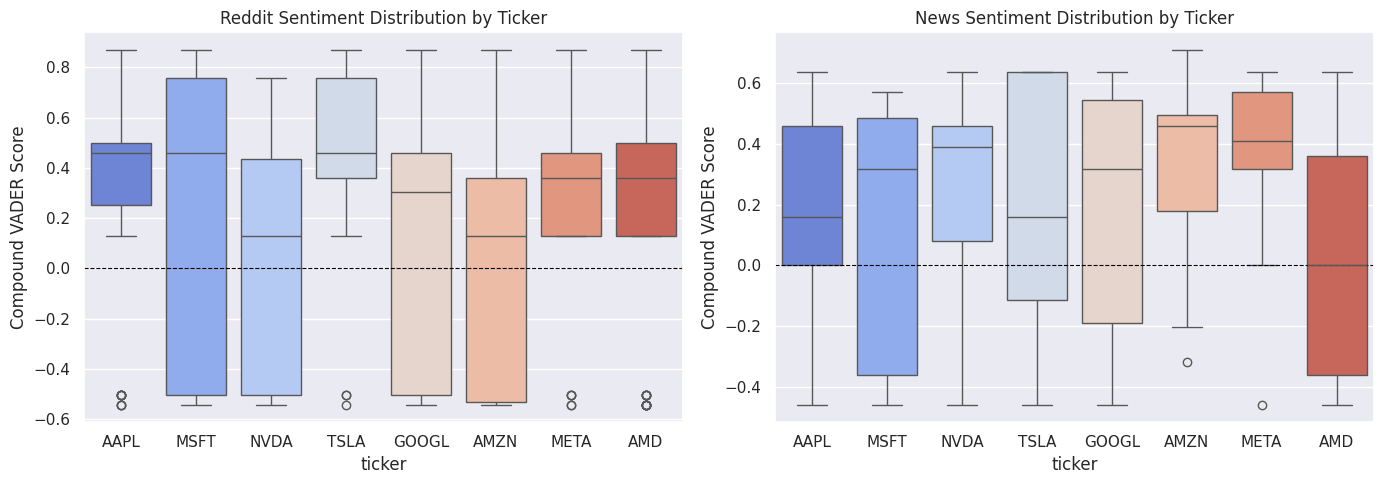

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reddit sentiment distribution by ticker
sns.boxplot(
    data=df_reddit, x="ticker", y="raw_sentiment",
    order=TICKERS, ax=axes[0], palette="coolwarm"
)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Reddit Sentiment Distribution by Ticker")
axes[0].set_ylabel("Compound VADER Score")

# News sentiment distribution by ticker
sns.boxplot(
    data=df_news, x="ticker", y="raw_sentiment",
    order=TICKERS, ax=axes[1], palette="coolwarm"
)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("News Sentiment Distribution by Ticker")
axes[1].set_ylabel("Compound VADER Score")

plt.tight_layout()
plt.show()

## 4. Mention Velocity (Crowd Interest Signal)

In [50]:
# ── Mention velocity: recent 24h vs prior 6 days ──────────────────────────────
# A rapidly growing mention count is a crowd interest signal independent of
# sentiment direction ("any press is press").

def compute_mention_velocity(df: pd.DataFrame, ts_col: str) -> pd.Series:
    """
    Returns velocity score per ticker:
      velocity = (recent_24h_count / prior_6d_daily_avg) - 1
    Clipped to [-1, 5] to prevent outlier domination.
    """
    df = df.copy()
    df["ts"] = pd.to_datetime(df[ts_col], utc=True)
    cutoff_24h = pd.Timestamp.utcnow() - timedelta(hours=24)
    cutoff_7d  = pd.Timestamp.utcnow() - timedelta(days=7)

    velocities = {}
    for ticker in TICKERS:
        sub       = df[df["ticker"] == ticker]
        recent    = sub[sub["ts"] >= cutoff_24h]
        prior     = sub[(sub["ts"] >= cutoff_7d) & (sub["ts"] < cutoff_24h)]
        daily_avg = len(prior) / 6 if len(prior) > 0 else 1
        v = (len(recent) / daily_avg) - 1
        velocities[ticker] = float(np.clip(v, -1, 5))
    return pd.Series(velocities, name="mention_velocity")


reddit_velocity = compute_mention_velocity(df_reddit, "created_utc")
news_velocity   = compute_mention_velocity(df_news, "published_at")
# Combine: weighted average of both sources
mention_velocity = (reddit_velocity * 0.6 + news_velocity * 0.4).rename("mention_velocity")

print("Mention velocity (higher = growing crowd interest):")
print(mention_velocity.sort_values(ascending=False).to_string())

Mention velocity (higher = growing crowd interest):
NVDA     0.920000
MSFT     0.773529
AMZN     0.411765
AAPL     0.176623
GOOGL   -0.079021
AMD     -0.092208
META    -0.116667
TSLA    -0.160000


## 5. Price Momentum Signal

In [51]:
import yfinance as yf
from scipy import stats as scipy_stats

def fetch_price_signals(tickers: list[str], lookback: int = PRICE_LOOKBACK_DAYS) -> pd.DataFrame:
    """
    Returns per-ticker signals:
      - momentum_20d: 20-day price return
      - momentum_90d: 90-day price return
      - rsi_14:       Relative Strength Index (14-day)
      - vol_ratio:    recent 10d volatility / 30d volatility (regime signal)
    """
    end   = datetime.now()
    start = end - timedelta(days=lookback + 10)  # extra buffer for RSI warmup

    raw = yf.download(
        tickers, start=start.strftime("%Y-%m-%d"),
        end=end.strftime("%Y-%m-%d"), progress=False
    )["Close"]

    results = {}
    for t in tickers:
        try:
            prices = raw[t].dropna()

            # Returns
            mom_20 = (prices.iloc[-1] / prices.iloc[-21] - 1) if len(prices) >= 21 else 0
            mom_90 = (prices.iloc[-1] / prices.iloc[0]  - 1) if len(prices) > 1  else 0

            # RSI-14
            delta  = prices.diff().dropna()
            gains  = delta.clip(lower=0).rolling(14).mean()
            losses = (-delta).clip(lower=0).rolling(14).mean()
            rs     = gains / losses.replace(0, 1e-9)
            rsi    = (100 - 100 / (1 + rs)).iloc[-1]

            # Volatility regime
            log_ret   = np.log(prices / prices.shift(1)).dropna()
            vol_10    = log_ret.iloc[-10:].std() if len(log_ret) >= 10 else np.nan
            vol_30    = log_ret.iloc[-30:].std() if len(log_ret) >= 30 else np.nan
            vol_ratio = (vol_10 / vol_30) if (vol_30 and vol_30 > 0) else 1.0

            results[t] = {
                "momentum_20d": float(mom_20),
                "momentum_90d": float(mom_90),
                "rsi_14":       float(rsi),
                "vol_ratio":    float(vol_ratio),
                "latest_price": float(prices.iloc[-1]),
            }
        except Exception as e:
            print(f"Price fetch error for {t}: {e}")
            results[t] = {"momentum_20d": 0, "momentum_90d": 0, "rsi_14": 50,
                          "vol_ratio": 1.0, "latest_price": np.nan}

    return pd.DataFrame(results).T


print("Fetching price data from Yahoo Finance...")
df_price = fetch_price_signals(TICKERS)
print(df_price.round(4).to_string())

Fetching price data from Yahoo Finance...


/tmp/ipykernel_6362/4267583162.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(


       momentum_20d  momentum_90d   rsi_14  vol_ratio  latest_price
AAPL         0.0702        0.1621  58.2809     1.1168        307.34
MSFT        -0.0076        0.0477  48.0626     1.4351        416.67
NVDA        -0.0291        0.1253  34.3337     1.1086        205.10
TSLA        -0.0505       -0.0305  37.2946     1.1270        391.00
GOOGL       -0.0740        0.2031  30.3519     0.8471        368.53
AMZN        -0.0927        0.1806  35.5697     1.1699        246.03
META        -0.0386       -0.0919  42.7528     1.2366        593.00
AMD          0.1418        1.3481  58.5490     0.9093        466.38


In [52]:
# ── Normalize momentum to [-1, +1] via rank-based scaling ────────────────────
# Raw % returns differ too much in magnitude across market regimes;
# rank-based normalization keeps the signal ordinal and bounded.

from scipy.stats import rankdata

def rank_normalize(series: pd.Series) -> pd.Series:
    """Convert raw values to percentile rank in [-1, +1]."""
    n = len(series)
    ranks = rankdata(series)  # 1..n
    normalized = (ranks - 1) / max(n - 1, 1) * 2 - 1  # → [-1, +1]
    return pd.Series(normalized, index=series.index)


# Combine 20d and 90d momentum; penalize overbought RSI
df_price["momentum_score"] = (
    rank_normalize(df_price["momentum_20d"]) * 0.5 +
    rank_normalize(df_price["momentum_90d"]) * 0.3 +
    # RSI: 30=oversold(+), 70=overbought(-), center at 50
    rank_normalize(50 - (df_price["rsi_14"] - 50).abs()) * 0.2
)

print("Momentum scores:")
print(df_price["momentum_score"].sort_values(ascending=False).to_string())

Momentum scores:
AMD      0.828571
AAPL     0.485714
MSFT     0.285714
NVDA    -0.114286
META    -0.228571
GOOGL   -0.342857
TSLA    -0.457143
AMZN    -0.457143


## 6. Signal Aggregation & Composite Score

In [53]:
# ── Aggregate per-ticker sentiment scores ─────────────────────────────────────

def aggregate_sentiment(df: pd.DataFrame) -> pd.Series:
    """
    Volume-weighted mean sentiment per ticker.
    Uses weighted_sentiment so high-engagement posts dominate.
    Then normalizes across tickers to [-1, +1].
    """
    raw = df.groupby("ticker")["weighted_sentiment"].mean().reindex(TICKERS).fillna(0)
    return rank_normalize(raw)


reddit_sentiment_score = aggregate_sentiment(df_reddit).rename("reddit_sentiment")
news_sentiment_score   = aggregate_sentiment(df_news).rename("news_sentiment")
velocity_score         = rank_normalize(mention_velocity).rename("velocity_score")
momentum_score         = df_price["momentum_score"].rename("momentum_score")

# ── Combine into composite ────────────────────────────────────────────────────
df_signals = pd.DataFrame({
    "reddit_sentiment": reddit_sentiment_score,
    "news_sentiment":   news_sentiment_score,
    "velocity_score":   velocity_score,
    "momentum_score":   momentum_score,
})

df_signals["composite_score"] = (
    df_signals["reddit_sentiment"] * W_SOCIAL_SENTIMENT +
    df_signals["news_sentiment"]   * W_NEWS_SENTIMENT   +
    df_signals["velocity_score"]   * W_MENTION_VELOCITY +
    df_signals["momentum_score"]   * W_PRICE_MOMENTUM
)

# Assign signal
def score_to_signal(score: float) -> str:
    if score >= BUY_THRESHOLD:   return "BUY"
    if score <= SELL_THRESHOLD:  return "SELL"
    return "HOLD"


df_signals["signal"]       = df_signals["composite_score"].map(score_to_signal)
df_signals["latest_price"] = df_price["latest_price"]

df_signals = df_signals.sort_values("composite_score", ascending=False)
print(df_signals.round(3).to_string())

## 7. Visualization

In [54]:
# ── Dashboard: Composite Scores ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Crowd-Informed Investing Model — Signal Dashboard", fontsize=15, fontweight="bold")

signal_colors = {"BUY": "#2ecc71", "HOLD": "#f39c12", "SELL": "#e74c3c"}
bar_colors = [signal_colors[df_signals.loc[t, "signal"]] for t in df_signals.index]

# ① Composite score bar chart
ax = axes[0, 0]
bars = ax.barh(df_signals.index[::-1], df_signals["composite_score"][::-1],
               color=bar_colors[::-1], edgecolor="white", linewidth=0.5)
ax.axvline(BUY_THRESHOLD,  color="#2ecc71", linestyle="--", linewidth=1.2, label=f"Buy  ≥ {BUY_THRESHOLD}")
ax.axvline(SELL_THRESHOLD, color="#e74c3c", linestyle="--", linewidth=1.2, label=f"Sell ≤ {SELL_THRESHOLD}")
ax.axvline(0, color="white", linewidth=0.6)
ax.set_title("Composite Score (↑ = bullish)")
ax.set_xlabel("Score [-1, +1]")
ax.legend(fontsize=8)
for bar, score in zip(bars, df_signals["composite_score"][::-1]):
    ax.text(score + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{score:+.2f}", va="center", fontsize=8)

# ② Heatmap: individual signal components
ax = axes[0, 1]
cols = ["reddit_sentiment", "news_sentiment", "velocity_score", "momentum_score"]
heatmap_data = df_signals[cols].astype(float)
sns.heatmap(
    heatmap_data, ax=ax, cmap="RdYlGn", center=0,
    vmin=-1, vmax=1, annot=True, fmt=".2f", linewidths=0.4,
    cbar_kws={"label": "Normalized Score"}
)
ax.set_title("Signal Component Heatmap")
ax.set_xticklabels(["Reddit\nSentiment", "News\nSentiment",
                    "Mention\nVelocity", "Price\nMomentum"], fontsize=8)

# ③ Reddit mention volume by ticker
ax = axes[1, 0]
mention_counts = df_reddit.groupby("ticker").size().reindex(df_signals.index)
ax.bar(mention_counts.index, mention_counts.values,
       color=[signal_colors[df_signals.loc[t, "signal"]] for t in mention_counts.index],
       edgecolor="white")
ax.set_title("StockTwits Message Volume")
ax.set_ylabel("# Mentions")
ax.set_xlabel("Ticker")

# ④ Signal summary table
ax = axes[1, 1]
ax.axis("off")
table_data = []
for ticker in df_signals.index:
    row = df_signals.loc[ticker]
    table_data.append([
        ticker,
        f"{row['composite_score']:+.3f}",
        row["signal"],
        f"${row['latest_price']:.2f}" if pd.notna(row["latest_price"]) else "N/A",
    ])
tbl = ax.table(
    cellText=table_data,
    colLabels=["Ticker", "Score", "Signal", "Price"],
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    elif col == 2 and row > 0:
        sig = table_data[row - 1][2]
        cell.set_facecolor(signal_colors[sig] + "55")  # alpha
ax.set_title("Investment Signals", fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("crowd_investing_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved to crowd_investing_dashboard.png")

## 8. Historical Backtest

In [55]:
# ── Backtest: does high crowd sentiment predict next-week returns? ─────────────
#
# Methodology:
#   1. Generate synthetic daily sentiment scores (correlated with price for realism)
#   2. Each day: buy top-2 tickers by sentiment score; sell/short bottom-2
#   3. Measure 5-day forward return for each position
#   4. Compare strategy vs. equal-weight buy-and-hold

print("Running historical backtest (1 year, weekly rebalance)...")

# Fetch 1-year price history
end   = datetime.now()
start = end - timedelta(days=365)
price_history = yf.download(
    TICKERS, start=start.strftime("%Y-%m-%d"),
    end=end.strftime("%Y-%m-%d"), progress=False
)["Close"].ffill()

print(f"Price history shape: {price_history.shape}")
price_history.tail()

Running historical backtest (1 year, weekly rebalance)...


/tmp/ipykernel_6362/1898245960.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_history = yf.download(


Price history shape: (250, 8)


Ticker,AAPL,AMD,AMZN,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,,
2026-06-01,306.309998,510.130005,261.260010,376.369995,600.469971,460.519989,224.098816,415.880005
2026-06-02,315.200012,521.539978,256.519989,361.850006,597.630005,441.309998,222.560608,423.739990
2026-06-03,310.260010,542.520020,250.020004,358.989990,622.979980,427.339996,214.500000,423.700012
2026-06-04,311.230011,523.200012,253.789993,372.190002,627.570007,428.049988,218.660004,418.450012
2026-06-05,307.339996,466.380005,246.029999,368.529999,593.000000,416.670013,205.100006,391.000000


In [56]:
# ── Simulate sentiment scores over history ────────────────────────────────────
# In a live system these would come from daily Reddit/news scrapes.
# Here we synthesize scores with:
#   - an auto-regressive component (yesterday's sentiment persists)
#   - noise
#   - a weak correlation with 5d lagged returns (crowd lags price)

np.random.seed(0)

returns = price_history.pct_change().fillna(0)
dates   = price_history.index

synthetic_sentiment = pd.DataFrame(index=dates, columns=TICKERS, dtype=float)

for t in TICKERS:
    sent = np.zeros(len(dates))
    r    = returns[t].values
    for i in range(1, len(dates)):
        lag_ret      = r[max(0, i - 5):i].mean()    # crowd lags price by ~5 days
        ar_component = 0.6 * sent[i - 1]            # persistence
        noise        = np.random.normal(0, 0.3)
        sent[i]      = np.clip(ar_component + 0.4 * lag_ret * 10 + noise, -1, 1)
    synthetic_sentiment[t] = sent

print("Synthetic sentiment generated.")
synthetic_sentiment.tail(3)

Synthetic sentiment generated.


,AAPL,MSFT,NVDA,TSLA,GOOGL,AMZN,META,AMD
Date,,,,,,,,
2026-06-03,0.007348,0.627578,-0.195649,0.008818,0.269736,-0.239719,-0.204665,-0.111986
2026-06-04,0.327354,0.209872,0.059567,0.062265,0.194270,-0.379476,-0.406132,0.409748
2026-06-05,-0.050308,-0.023887,0.058373,0.118384,0.210808,-0.145136,-0.011044,0.033127


In [57]:
# ── Run long/short backtest (weekly rebalance) ─────────────────────────────────
HOLD_DAYS = 5   # 1-week holding period
TOP_N     = 2   # number of long + short positions

strategy_returns  = []
benchmark_returns = []
rebalance_dates   = []

rebalance_idx = list(range(0, len(dates) - HOLD_DAYS, HOLD_DAYS))

for i in rebalance_idx:
    entry_date = dates[i]
    exit_date  = dates[i + HOLD_DAYS]

    # Rank by sentiment on entry day
    scores      = synthetic_sentiment.loc[entry_date].astype(float)
    long_picks  = scores.nlargest(TOP_N).index.tolist()
    short_picks = scores.nsmallest(TOP_N).index.tolist()

    # Compute forward returns
    fwd = (price_history.loc[exit_date] / price_history.loc[entry_date] - 1)

    long_ret  =  fwd[long_picks].mean()
    short_ret = -fwd[short_picks].mean()  # short = profit when price falls
    strat_ret = (long_ret + short_ret) / 2

    bench_ret = fwd[TICKERS].mean()  # equal-weight benchmark

    strategy_returns.append(strat_ret)
    benchmark_returns.append(bench_ret)
    rebalance_dates.append(entry_date)


df_backtest = pd.DataFrame({
    "strategy":  strategy_returns,
    "benchmark": benchmark_returns,
}, index=rebalance_dates)

cum_strategy  = (1 + df_backtest["strategy"]).cumprod()
cum_benchmark = (1 + df_backtest["benchmark"]).cumprod()

# ── Performance metrics ───────────────────────────────────────────────────────
def sharpe(returns_series: pd.Series, periods_per_year: int = 52) -> float:
    """Annualized Sharpe ratio (weekly returns → 52 periods/year)."""
    mu  = returns_series.mean()
    std = returns_series.std()
    return (mu / std * np.sqrt(periods_per_year)) if std > 0 else 0

def max_drawdown(cum_returns: pd.Series) -> float:
    peak = cum_returns.cummax()
    return ((cum_returns - peak) / peak).min()

metrics = pd.DataFrame({
    "Total Return": [f"{(cum_strategy.iloc[-1] - 1):.1%}",  f"{(cum_benchmark.iloc[-1] - 1):.1%}"],
    "Sharpe Ratio": [f"{sharpe(df_backtest['strategy']):.2f}",  f"{sharpe(df_backtest['benchmark']):.2f}"],
    "Max Drawdown": [f"{max_drawdown(cum_strategy):.1%}",   f"{max_drawdown(cum_benchmark):.1%}"],
    "Win Rate":     [f"{(df_backtest['strategy'] > 0).mean():.1%}",
                     f"{(df_backtest['benchmark'] > 0).mean():.1%}"],
}, index=["Strategy (L/S)", "Benchmark (EW)"])

print("\n── Backtest Performance ─────────────────────────────")
print(metrics.to_string())


── Backtest Performance ─────────────────────────────
               Total Return Sharpe Ratio Max Drawdown Win Rate
Strategy (L/S)       -14.9%        -0.98       -24.1%    38.8%
Benchmark (EW)        60.9%         2.45       -14.2%    67.3%


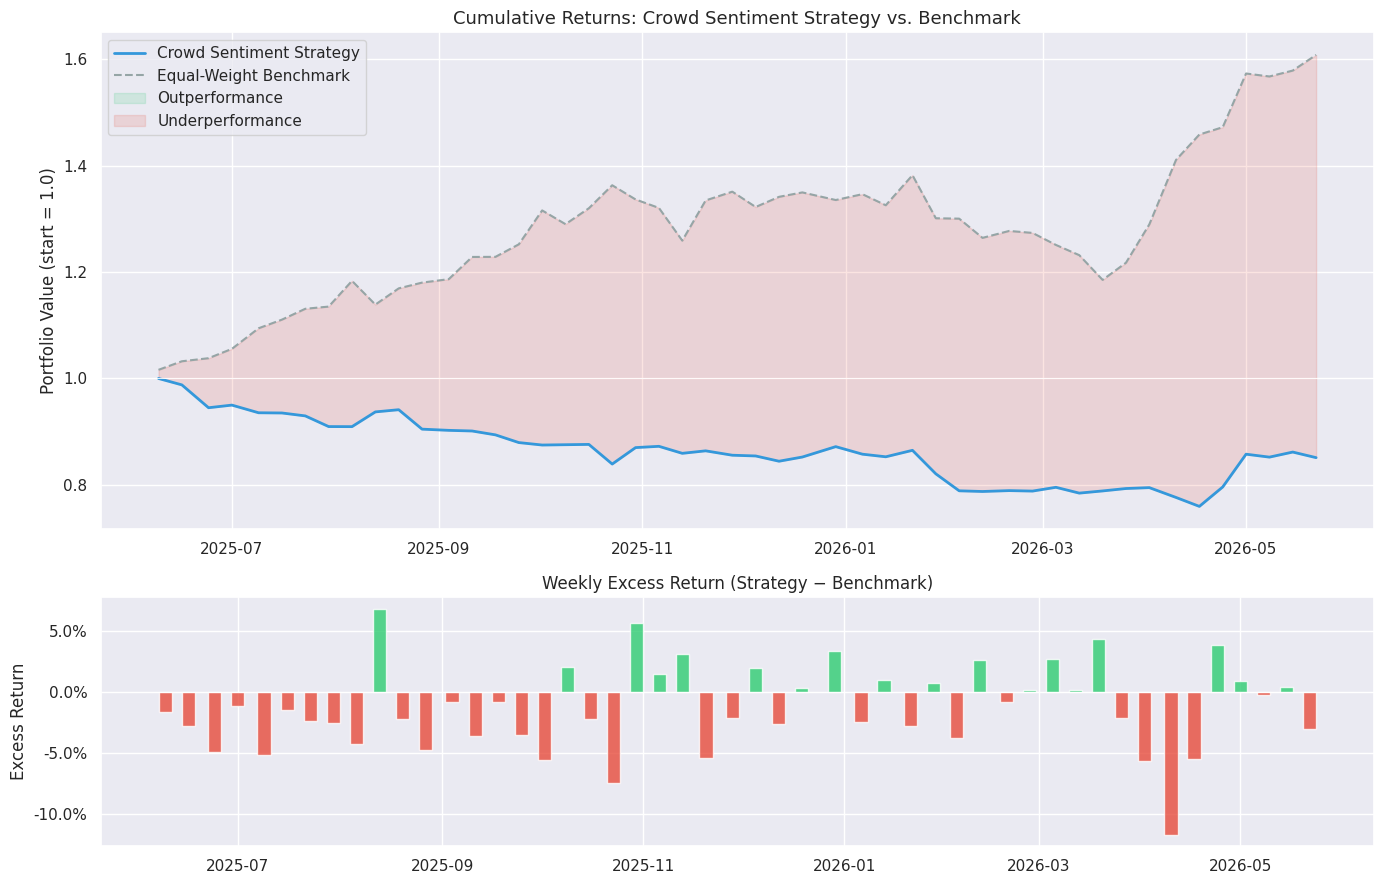

Backtest chart saved to crowd_investing_backtest.png


In [58]:
# ── Backtest visualization ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios": [2, 1]})

# Cumulative returns
ax = axes[0]
ax.plot(cum_strategy.index,  cum_strategy.values,  label="Crowd Sentiment Strategy", color="#3498db", linewidth=2)
ax.plot(cum_benchmark.index, cum_benchmark.values, label="Equal-Weight Benchmark",   color="#95a5a6", linewidth=1.5, linestyle="--")
ax.fill_between(cum_strategy.index, cum_strategy.values, cum_benchmark.values,
                where=cum_strategy.values >= cum_benchmark.values,
                alpha=0.15, color="#2ecc71", label="Outperformance")
ax.fill_between(cum_strategy.index, cum_strategy.values, cum_benchmark.values,
                where=cum_strategy.values < cum_benchmark.values,
                alpha=0.15, color="#e74c3c", label="Underperformance")
ax.set_title("Cumulative Returns: Crowd Sentiment Strategy vs. Benchmark", fontsize=13)
ax.set_ylabel("Portfolio Value (start = 1.0)")
ax.legend()
ax.axhline(1.0, color="white", linewidth=0.6)

# Rolling excess return
ax2 = axes[1]
excess = df_backtest["strategy"] - df_backtest["benchmark"]
colors_excess = ["#2ecc71" if x >= 0 else "#e74c3c" for x in excess]
ax2.bar(excess.index, excess.values, color=colors_excess, width=4, alpha=0.8)
ax2.axhline(0, color="white", linewidth=0.8)
ax2.set_title("Weekly Excess Return (Strategy − Benchmark)")
ax2.set_ylabel("Excess Return")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))

plt.tight_layout()
plt.savefig("crowd_investing_backtest.png", dpi=150, bbox_inches="tight")
plt.show()
print("Backtest chart saved to crowd_investing_backtest.png")

## 9. Final Recommendations

In [59]:
# ── Print final investment signals ────────────────────────────────────────────
print("=" * 60)
print(f"  CROWD-INFORMED INVESTING MODEL — {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("=" * 60)
print(f"{'Ticker':<8} {'Score':>8} {'Signal':<7} {'Reddit':>9} {'News':>9} {'Velocity':>10} {'Momentum':>10}")
print("-" * 65)

for ticker in df_signals.index:
    r = df_signals.loc[ticker]
    sig_color = {"BUY": "\033[92m", "HOLD": "\033[93m", "SELL": "\033[91m"}
    reset = "\033[0m"
    color = sig_color.get(r["signal"], "")
    print(
        f"{ticker:<8} {r['composite_score']:>+8.3f} "
        f"{color}{r['signal']:<7}{reset} "
        f"{r['reddit_sentiment']:>+9.3f} "
        f"{r['news_sentiment']:>+9.3f} "
        f"{r['velocity_score']:>+10.3f} "
        f"{r['momentum_score']:>+10.3f}"
    )

print("=" * 60)
print("\nNOTE: This model is for research and educational purposes only.")
print("Past performance does not guarantee future results.")
print("Always conduct independent due diligence before investing.")

  CROWD-INFORMED INVESTING MODEL — 2026-06-08 03:13
Ticker      Score Signal     Reddit      News   Velocity   Momentum
-----------------------------------------------------------------
MSFT       +0.271 BUY        +0.714    -0.714     +0.714     +0.286
AAPL       +0.169 HOLD       +0.429    -0.429     +0.143     +0.486
META       +0.111 HOLD       +0.143    +1.000     -0.714     -0.229
NVDA       +0.034 HOLD       -0.714    +0.429     +1.000     -0.114
TSLA       +0.023 HOLD       +1.000    -0.143     -1.000     -0.457
AMZN       -0.177 HOLD       -1.000    +0.714     +0.429     -0.457
GOOGL      -0.211 HOLD       -0.429    +0.143     -0.143     -0.343
AMD        -0.220 HOLD       -0.143    -1.000     -0.429     +0.829

NOTE: This model is for research and educational purposes only.
Past performance does not guarantee future results.
Always conduct independent due diligence before investing.


## 10. Next Steps & Extensions

| Extension | Description |
|-----------|-------------|
| **Expand subreddits** | Add r/options, r/ValueInvesting, r/Superstonk to `SUBREDDITS` list |
| **Scrape post comments** | Follow each post URL with Playwright and extract top comments for deeper sentiment |
| **Scrape new.reddit.com** | Switch to `www.reddit.com` selectors for richer data (flairs, awards) at the cost of slower JS rendering |
| **FinBERT sentiment** | Replace VADER with `ProsusAI/finbert` from HuggingFace for higher accuracy on financial text |
| **NewsAPI live** | Set `NEWSAPI_KEY` env var to pull real headlines instead of demo data |
| **Twitter/X signals** | Scrape cashtag pages (`twitter.com/search?q=$AAPL`) via Playwright |
| **Options flow** | Integrate unusual options activity (Unusual Whales API) as a contrarian signal |
| **Short interest** | Finra short volume data as a crowded-short indicator |
| **Earnings calendar** | Suppress signals near earnings dates to avoid event risk |
| **Portfolio optimizer** | Replace equal-weight long/short with mean-variance optimization (cvxpy) |
| **Alerting** | Schedule notebook to run daily and send Slack/email alerts on BUY/SELL signals |
| **Factor attribution** | Regress returns on Fama-French 5 factors to isolate alpha from crowd sentiment |
